210 209 205


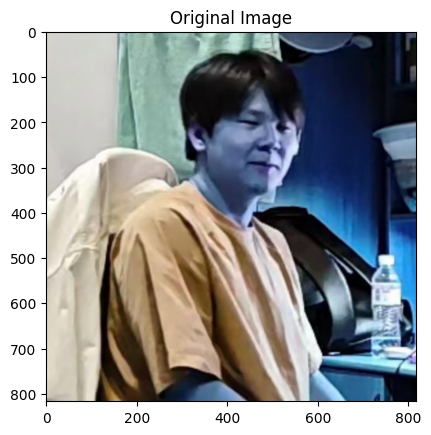

In [11]:
import cv2
from skimage.util import random_noise
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('sz.jpg')
(b,g,r)=img[100,100]
print(b, g, r)
plt.imshow(img)
plt.title('Original Image')
plt.savefig('save/original_bgr.jpg', dpi=300)
plt.show()

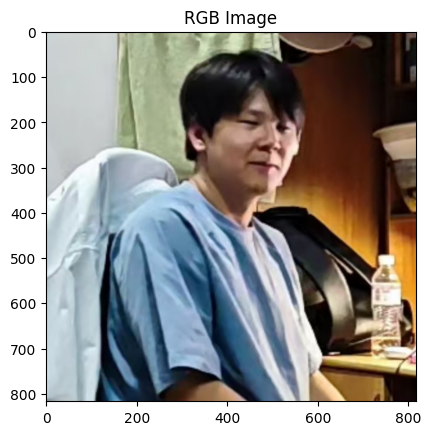

In [13]:
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img)
plt.title('RGB Image')
plt.savefig('save/rgb_image.jpg', dpi=300)
plt.show()

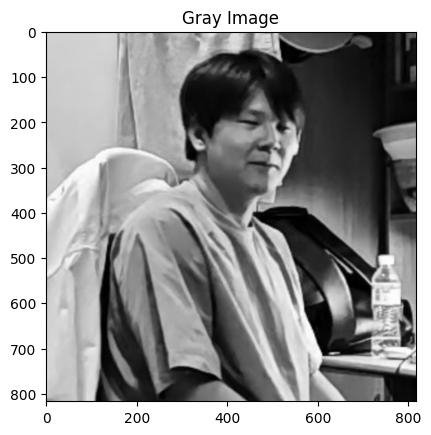

In [15]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')
plt.title('Gray Image')
plt.savefig('save/gray_image.jpg', dpi=300)
plt.show()

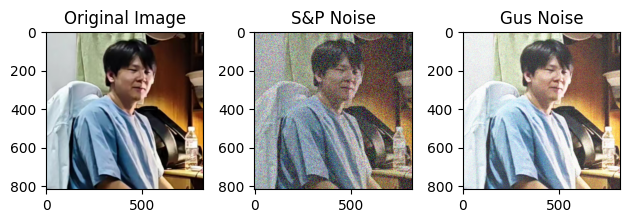

In [20]:
sp_noise_img = random_noise(rgb_img, mode='s&p', amount=0.4)
gus_noise_img = random_noise(rgb_img, mode='gaussian', mean=0.2, var=0.03)
plt.subplot(1, 3, 1)
plt.imshow(rgb_img, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 3, 2)
plt.imshow(sp_noise_img, cmap='gray')
plt.title('S&P Noise')
plt.subplot(1, 3, 3)
plt.imshow(gus_noise_img, cmap='gray')
plt.title('Gus Noise')

plt.tight_layout()
plt.savefig('save/noise_comparison.jpg', dpi=300)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.105427357601002e-17..0.9999999999999993].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10211207418914593..1.0000000000000027].


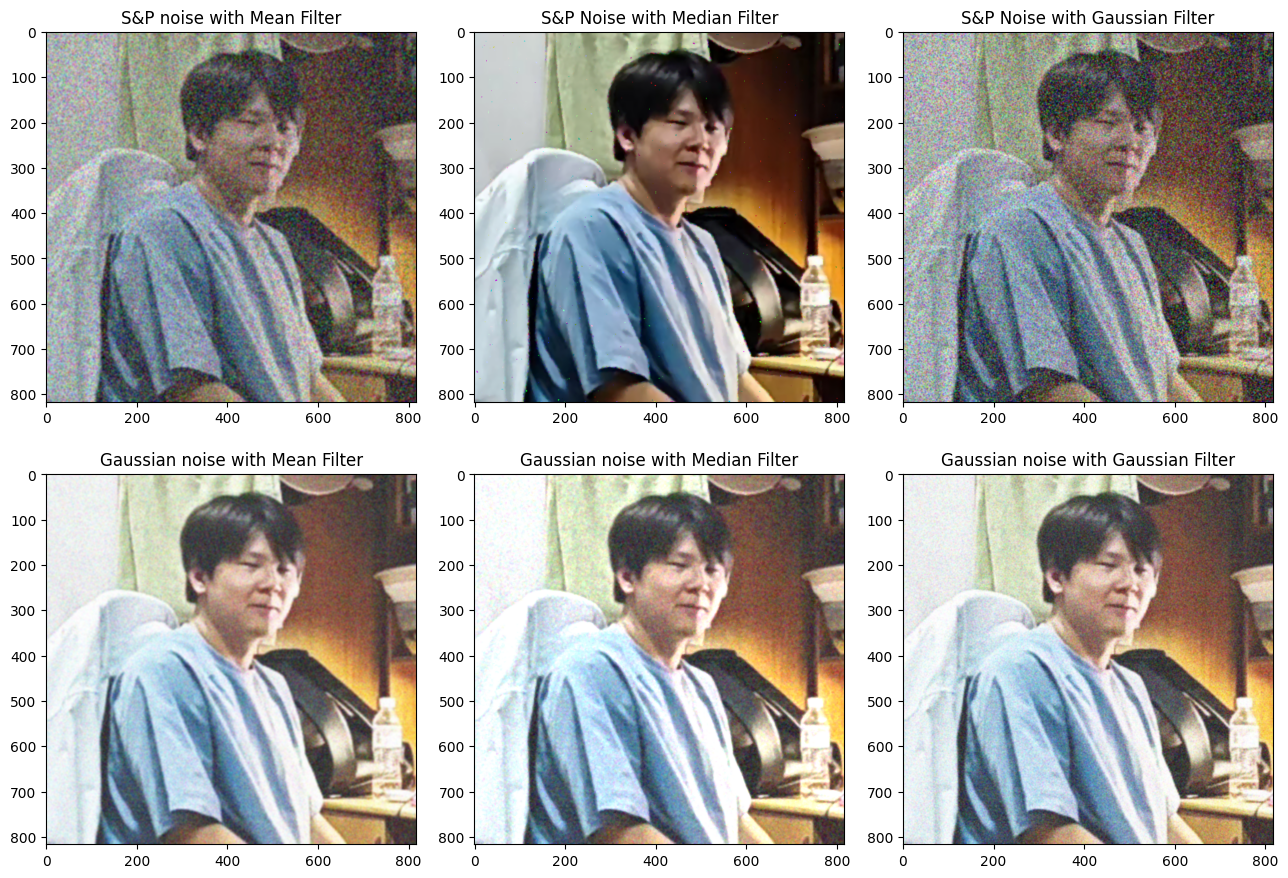

In [21]:
mean_sp = cv2.blur(sp_noise_img, (5, 5))
mean_gus = cv2.blur(gus_noise_img, (5, 5))

mid_sp = cv2.medianBlur((sp_noise_img*255).astype(np.uint8), 5)
mid_gus = cv2.medianBlur((gus_noise_img*255).astype(np.uint8), 5)

gauss_sp = cv2.GaussianBlur((sp_noise_img*255).astype(np.uint8), (5, 5), 0)
gauss_gus = cv2.GaussianBlur((gus_noise_img*255).astype(np.uint8), (5, 5), 0)

plt.figure(figsize=(13, 9))

plt.subplot(2, 3, 1)
plt.imshow(mean_sp)
plt.title("S&P noise with Mean Filter")

plt.subplot(2, 3, 2)
plt.imshow(mid_sp)
plt.title("S&P Noise with Median Filter")

plt.subplot(2, 3, 3)
plt.imshow(gauss_sp)
plt.title("S&P Noise with Gaussian Filter")

plt.subplot(2, 3, 4)
plt.imshow(mean_gus)
plt.title("Gaussian noise with Mean Filter")

plt.subplot(2, 3, 5)
plt.imshow(mid_gus)
plt.title("Gaussian noise with Median Filter")

plt.subplot(2, 3, 6)
plt.imshow(gauss_gus)
plt.title("Gaussian noise with Gaussian Filter")

plt.tight_layout()
plt.savefig('save/filter_results_2x3.jpg', dpi=300)
plt.show()
